In [6]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
import copy as cp

In [2]:
scenario = "linear_reward"
trial_number = 10
use_example = True
save_plot = False

In [ ]:
base_path = os.path.sep.join(os.path.abspath("__file__").split(os.path.sep)[:-2])
plot_path = os.path.join(base_path,"results",scenario,"plots")
folder_root = "trial"

sys.path.insert(0, os.path.join(base_path,"code/functions"))
os.makedirs(plot_path, exist_ok=True)

target_seed = np.arange(trial_number)

from global_variables import *
from linear_reward_variables import *
from linear_reward_functions import *
from plots import *
from stat_functions import *

del data_path
data_path = os.path.join("/data/suheecho/BTSP","data",scenario)

# data_path = os.path.join(base_path,"data",scenario) if use_example else os.path.join(base_path,"results",scenario)
ref_path = os.path.join(data_path,folder_root+str(target_seed[0]))
sys.path.append(ref_path)

/home/suheecho/BTSP/Rapid_Learning_Cognitive_Map/code/functions/common_functions.py:1543: SyntaxWarning: invalid escape sequence '\p'
  Pr(spikes|x) = \prod_{i=1}^N \frac{(\Delta t*tau_i(x))^n_i}{n_i!} e^{-\Delta t*tau_i(x)} (* uniform prior...)
/home/suheecho/BTSP/Rapid_Learning_Cognitive_Map/code/functions/common_functions.py:1599: SyntaxWarning: invalid escape sequence '\s'
  R(v, rho) = \frac{1}{n} \sum_{k=1}^n-1 Pr(|pos - (rho + v*k*\Delta t)| < d)


In [4]:
seed = target_seed[5]
foldername = folder_root + str(seed)
place_thr_FR = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_10.npz"))["place_thr_FR"]

CA1_activity_before = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_10.npz"))["CA1_activity"]
CA1_PF_before = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_10.pkl"))
place_div_idx_before = np.hstack((np.array(list(CA1_PF_before.keys())),np.setdiff1d(np.arange(num_CA1_neurons),np.array(list(CA1_PF_before.keys())))))

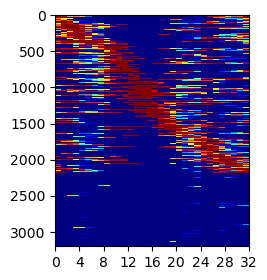

In [7]:
act_thr = 3.5
pop_act = CA1_activity_before.mean(-1)
thr_idx = np.where(pop_act>act_thr)[0]

inhibited_CA1_activity = cp.copy(CA1_activity_before)

for ii in thr_idx:
    data = CA1_activity_before[ii]
    sort_idx = np.argsort(data); sort_idx = sort_idx[::-1] # Descending order
    temp_sum = np.cumsum(data[sort_idx])/data.size
    data[sort_idx[np.where(temp_sum>=act_thr)[0][0]:]] = 0
    inhibited_CA1_activity[ii] = data
xlab = []

for ii in range(num_state_total):
    xlab.append("%d"%(ii))

data = inhibited_CA1_activity[:, place_div_idx_before].T
# Create meshgrid for pcolormesh
x = np.arange(data.shape[1] + 1)
y = np.arange(data.shape[0] + 1)

plt.figure(figsize=(2.5, 3))
plt.pcolormesh(x, y, data, cmap='jet', shading='auto',vmin=0,vmax=max_input_FR)  # shading='auto' avoids shape mismatch

plt.gca().yaxis.set_inverted(True)
plt.xticks(np.linspace(0,int(data.shape[1]/num_state_total)*num_state_total,num_state_total+1))
plt.show()

# plt.savefig(os.path.join(plotPath,"CA1_placefields_episode_"+str(load_episode)+".svg"), format="svg")

In [10]:
act_thr = 3.5
act_window = int(3 * unit_gran)

def inhibit_overactive_positions(activity_array, act_thr):
    """At positions where population activity exceeds `act_thr`, zero out the
    least-active neurons until the remaining activity falls back under `act_thr`
    (mimics lateral inhibition)."""
    inhibited = cp.deepcopy(activity_array)
    overactive_pos = np.where(inhibited.mean(-1) > act_thr)[0]
    for pos in overactive_pos:
        data = inhibited[pos]
        sort_idx = np.argsort(data)[::-1]
        cum_activity = np.cumsum(data[sort_idx]) / data.size
        cutoff = np.where(cum_activity >= act_thr)[0][0]
        data[sort_idx[cutoff:]] = 0
    return inhibited

def get_rw_nrw_activity(activity_array, place_thr_FR, unit_gran, act_window):
    """Split place cells into reward-zone (state index 3) vs. non-reward cells
    and average their peak-aligned activity profiles."""
    place_cell_idx = np.where(np.max(activity_array, axis=0) >= place_thr_FR)[0]
    peak_idx = find_PF_peak(activity_array)

    rw_idx = np.intersect1d(place_cell_idx, np.where((peak_idx >= 3 * unit_gran) & (peak_idx < 4 * unit_gran))[0])
    nrw_idx = np.setdiff1d(place_cell_idx, rw_idx)

    rw_activity = extract_aligned_activity(activity_array[:, rw_idx], peak_idx[rw_idx], act_window).mean(0)
    nrw_activity = extract_aligned_activity(activity_array[:, nrw_idx], peak_idx[nrw_idx], act_window).mean(0)
    return rw_activity, nrw_activity

rw_act = np.zeros((2, len(target_seed), 2 * act_window + 1))
nrw_act = np.zeros((2, len(target_seed), 2 * act_window + 1))

for ss, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    activity_file = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_10.npz"))
    CA1_activity_array = activity_file["CA1_activity"]
    place_thr_FR = activity_file["place_thr_FR"]

    rw_act[0, ss], nrw_act[0, ss] = get_rw_nrw_activity(CA1_activity_array, place_thr_FR, unit_gran, act_window)

    inhibited_CA1_act = inhibit_overactive_positions(CA1_activity_array, act_thr)
    rw_act[1, ss], nrw_act[1, ss] = get_rw_nrw_activity(inhibited_CA1_act, place_thr_FR, unit_gran, act_window)

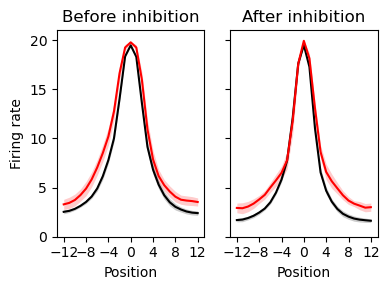

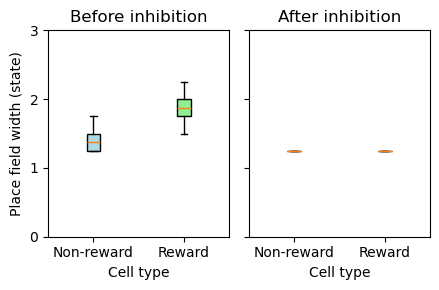

Before inhibition, reward vs. non-reward PF width: p=0.0001924, p_fdr=0.0003847, d=-1.911, 95% CI [-2.6114, -1.1886]
After inhibition, reward vs. non-reward PF width: p=1, p_fdr=1, d=0.000, 95% CI [-0.3372, 0.3372]


In [11]:
data_rw_bf, std_rw_bf = rw_act[0].mean(0), rw_act[0].std(0)
data_nrw_bf, std_nrw_bf = nrw_act[0].mean(0), nrw_act[0].std(0)
data_rw_af, std_rw_af = rw_act[1].mean(0), rw_act[1].std(0)
data_nrw_af, std_nrw_af = nrw_act[1].mean(0), nrw_act[1].std(0)

xx = np.arange(-act_window, act_window + 1)
xticks = np.linspace(-act_window, act_window, 2 * act_window // unit_gran + 1)

fig, axs = plt.subplots(1, 2, figsize=(4, 3), sharey=True)
plot_shaded(xx, data_nrw_bf, std_nrw_bf, ax=axs[0], color='black')
plot_shaded(xx, data_rw_bf, std_rw_bf, ax=axs[0], color='red')
plot_shaded(xx, data_nrw_af, std_nrw_af, ax=axs[1], color='black')
plot_shaded(xx, data_rw_af, std_rw_af, ax=axs[1], color='red')

for ax, title in zip(axs, ["Before inhibition", "After inhibition"]):
    ax.set_title(title)
    ax.set_xlabel("Position")
    ax.set_xticks(xticks)
    ax.set_ylim([0, max_input_FR + 1])
axs[0].set_ylabel("Firing rate")
plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "linear_reward_Placefield_rw_nrw.svg"), format="svg")
plt.show()

# Place-field width: number of consecutive above-threshold bins spanning the peak
width_thr = 10
mid = act_window

def pf_width(activity, thr, mid):
    right = np.where(activity[mid:] < thr)[0]
    left = np.where(activity[:mid][::-1] < thr)[0]
    right_edge = right[0] if right.size else mid
    left_edge = left[0] if left.size else mid
    return right_edge + left_edge

rw_PF_width_bf = [pf_width(rw_act[0, ss], width_thr, mid) for ss in range(len(target_seed))]
rw_PF_width_af = [pf_width(rw_act[1, ss], width_thr, mid) for ss in range(len(target_seed))]
nrw_PF_width_bf = [pf_width(nrw_act[0, ss], width_thr, mid) for ss in range(len(target_seed))]
nrw_PF_width_af = [pf_width(nrw_act[1, ss], width_thr, mid) for ss in range(len(target_seed))]

fig, axs = plt.subplots(1, 2, figsize=(4.5, 3), sharey=True)
plot_box(nrw_PF_width_bf, rw_PF_width_bf, axs[0])
plot_box(nrw_PF_width_af, rw_PF_width_af, axs[1])

y_max = max(rw_PF_width_bf + nrw_PF_width_bf + rw_PF_width_af + nrw_PF_width_af)
y_ticks = np.arange(0, y_max + unit_gran, unit_gran)
for ax, title in zip(axs, ["Before inhibition", "After inhibition"]):
    ax.set_title(title)
    ax.set_xlabel("Cell type")
    ax.set_xticklabels(["Non-reward", "Reward"])
    ax.set_yticks(y_ticks)
axs[0].set_ylabel("Place field width (state)"); axs[0].set_yticklabels(y_ticks//unit_gran)
plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "linear_reward_PFwidth_rw_nrw.svg"), format="svg")
plt.show()

# Paired t-tests (reward vs. non-reward place-field width), FDR-corrected across before/after inhibition
_, p_bf = stats.ttest_rel(rw_PF_width_bf, nrw_PF_width_bf)
_, p_af = stats.ttest_rel(rw_PF_width_af, nrw_PF_width_af)
_, p_fdr, _, _ = multipletests([p_bf, p_af], method='fdr_bh')

pf_test_cases = [
    ("Before inhibition", nrw_PF_width_bf, rw_PF_width_bf),
    ("After inhibition", nrw_PF_width_af, rw_PF_width_af),
]
for (label, rw_width, nrw_width), p, p_q in zip(pf_test_cases, [p_bf, p_af], p_fdr):
    d = cohens_d_paired(rw_width, nrw_width)
    ci_lo, ci_hi = ci_paired(rw_width, nrw_width)
    print(f"{label}, reward vs. non-reward PF width: p={p:.4g}, p_fdr={p_q:.4g}, "
          f"d={d:.3f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")